# Baseline Risk Premium Model: Frequency × Severity with `glum`

**Goal:** build an explainable *risk premium* (pure premium) model for French motor third-party liability (freMTPL2) using generalised linear models (GLMs).

The risk premium is the expected claims cost per policy per year. It is split into two parts that are modelled separately:

$$
\underbrace{\mathbb{E}\left[\tfrac{\text{cost}}{\text{exposure}}\right]}_{\text{risk premium}}
= \underbrace{\mathbb{E}\left[\tfrac{N}{\text{exposure}}\right]}_{\text{frequency}}
\times \underbrace{\mathbb{E}[X \mid \text{claim}]}_{\text{severity}}
$$

- **Frequency**: how *often* a policy claims (claims per year). Modelled with a **Poisson GLM**.
- **Severity**: how *much* a claim costs on average. Modelled with a **Gamma GLM**.

**Why split it?** Different risk factors drive the two parts (young drivers crash more often, but their claims aren't necessarily more expensive), and each part has a natural statistical distribution. The split also makes the model easier to explain: you can say *why* a policy is expensive.

**Assumption:** given the rating factors, the number of claims and the claim size are independent, so the expectations can be multiplied.

**Why GLMs?** With a log link, a GLM produces a *multiplicative tariff*: a base premium × one relativity per rating factor. This is the industry standard in P&C pricing, because every number in the tariff can be read, challenged and signed off by an actuary.

This notebook builds the **baseline**: a deliberately simple model that later candidate models must beat.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glum import GeneralizedLinearRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance

from autorp.load_data import load_freq, load_sev

SEED = 42                   # fixed seed -> the train/test split (and so all results) are reproducible
LARGE_CLAIM_CAP = 100_000   # individual claims are capped at this amount for the severity model (see section 2)

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Load the data

Two tables from OpenML:

| Table | Grain | Content |
|---|---|---|
| `freMTPL2freq` | one row per **policy** | exposure (fraction of a year insured), number of claims, rating factors |
| `freMTPL2sev` | one row per **claim** | policy ID and claim amount (€) |

Rating factors: `Area` (A–F, rural → urban), `VehPower`, `VehAge`, `DrivAge`, `BonusMalus` (French no-claims scale: 50 = best, >100 = malus), `VehBrand`, `VehGas`, `Density` (inhabitants/km²), `Region`.

In [2]:
freq = load_freq()
sev = load_sev()
print(f"freq: {freq.shape[0]:,} policies, sev: {sev.shape[0]:,} claims")
freq.head()

freq: 678,013 policies, sev: 26,639 claims


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


## 2. Data cleaning

Problems found when inspecting the raw data, and how each is handled:

| Issue | Fix | Why |
|---|---|---|
| `IDpol` is a float in the frequency table | cast to `int` | needed to join the two tables on policy ID |
| `VehGas` values contain quotes (`'Diesel'`) | strip them | an artefact of the OpenML file format |
| ~9k policies have `ClaimNb > 0` but **no claim amounts** | take claim counts **from the severity table** | frequency and severity must describe *the same claims*. Otherwise frequency counts claims that have no cost, and frequency × severity overstates the premium. |
| A few `Exposure` values > 1 year | cap at 1 | policies are annual; > 1 is a data error |
| A few policies with 5–66 claims | cap the **frequency** count at 4 | almost certainly data errors (or fleet-like policies) that would distort the Poisson fit |
| A handful of very large claims (up to €4m) | cap each claim at €100k for severity, then add a **large-loss loading** | a few extreme claims would dominate the Gamma fit. Large losses are mostly random, so they are spread over the whole portfolio as a flat loading. |

Large claims are capped **per claim**, before claims are summed per policy.

In [3]:
freq["IDpol"] = freq["IDpol"].astype(int)
freq["VehGas"] = freq["VehGas"].astype(str).str.strip("'").astype("category")

sev["ClaimAmountCapped"] = sev["ClaimAmount"].clip(upper=LARGE_CLAIM_CAP)

# one row per policy: number of claims with a known cost, total cost (raw and capped)
claims = sev.groupby("IDpol").agg(
    ClaimCount=("ClaimAmount", "size"),
    ClaimAmount=("ClaimAmount", "sum"),
    ClaimAmountCapped=("ClaimAmountCapped", "sum"),
)

df = freq.merge(claims, left_on="IDpol", right_index=True, how="left")
df[["ClaimCount", "ClaimAmount", "ClaimAmountCapped"]] = df[["ClaimCount", "ClaimAmount", "ClaimAmountCapped"]].fillna(0)
df["ClaimCount"] = df["ClaimCount"].astype(int)

df["Exposure"] = df["Exposure"].clip(upper=1.0)
df["ClaimNbFreq"] = df["ClaimCount"].clip(upper=4)   # claim count used by the frequency model

print(f"Policies with ClaimNb > 0 but no cost record: {((df.ClaimNb > 0) & (df.ClaimCount == 0)).sum():,}")
print(f"Claims in sev not matching any policy (dropped): {(~claims.index.isin(df.IDpol)).sum()}")
print(f"Share of total cost above the €{LARGE_CLAIM_CAP:,} cap: {1 - sev.ClaimAmountCapped.sum() / sev.ClaimAmount.sum():.1%} "
      f"(from {(sev.ClaimAmount > LARGE_CLAIM_CAP).sum()} claims)")

Policies with ClaimNb > 0 but no cost record: 9,116
Claims in sev not matching any policy (dropped): 6
Share of total cost above the €100,000 cap: 17.7% (from 42 claims)


## 3. Portfolio overview

Headline numbers. The rest of the notebook explains how these vary across policies.

In [4]:
expo = df.Exposure.sum()
n = df.ClaimCount.sum()
cost = df.ClaimAmount.sum()
pd.Series({
    "Policies": len(df),
    "Exposure (years)": expo,
    "Claims": n,
    "Claim frequency (per year)": n / expo,
    "Average severity (€)": cost / n,
    "Average severity, capped (€)": df.ClaimAmountCapped.sum() / n,
    "Risk premium (€ per year)": cost / expo,
}).to_frame("value").style.format("{:,.4f}")

,value
Policies,"678,013.0000"
Exposure (years),"358,360.1055"
Claims,"26,444.0000"
Claim frequency (per year),0.0738
Average severity (€),"2,265.5126"
"Average severity, capped (€)","1,864.4001"
Risk premium (€ per year),167.1760


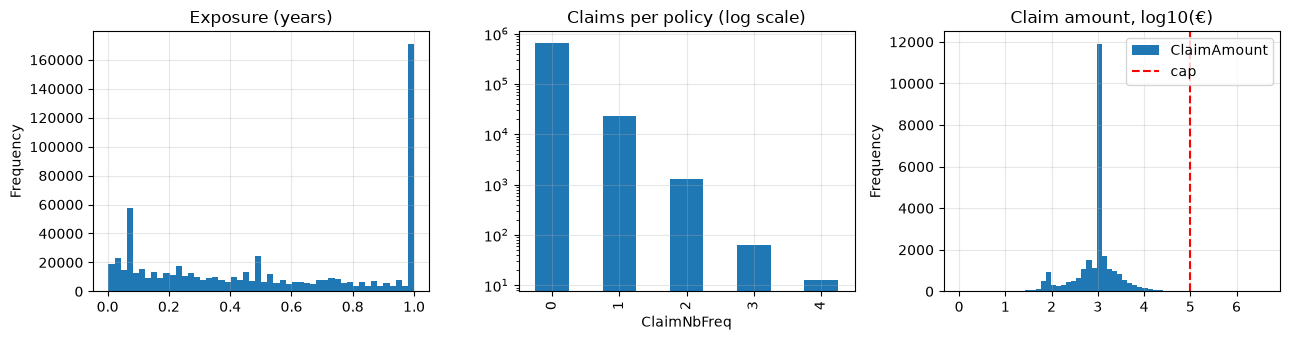

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
df.Exposure.plot.hist(bins=50, ax=axes[0], title="Exposure (years)")
df.ClaimNbFreq.value_counts().sort_index().plot.bar(ax=axes[1], title="Claims per policy (log scale)", logy=True)
np.log10(sev.ClaimAmount).plot.hist(bins=60, ax=axes[2], title="Claim amount, log10(€)")
axes[2].axvline(np.log10(LARGE_CLAIM_CAP), color="red", ls="--", label="cap")
axes[2].legend()
plt.tight_layout()

**What we see**
- Exposure is spread between 0 and 1: many policies are only observed for part of the year. The model must account for this; it's what the exposure weight in section 6 does.
- ~95% of policies have no claim. Claims are rare events, which is why a Poisson model fits.
- Claim amounts are heavily right-skewed: most claims cost about €1,000–2,000, with a long tail. This is why a Gamma model (or capping) is used, not a normal distribution.

## 4. One-way analysis

A **one-way** shows, for one variable at a time, the exposure (grey bars) and the observed frequency / severity (lines) per level.

What one-ways are for:
- spotting which variables carry signal,
- seeing the *shape* of the effect (linear, U-shaped, flat), which guides banding,
- finding thin levels (little exposure) that need grouping.

**Limitation:** one-ways can mislead when variables are correlated. For example, young drivers often drive older cars, so part of the "old car" effect in a one-way may really be a "young driver" effect. A GLM estimates all effects *at the same time* and so separates them. That's why we fit a model rather than read the tariff off one-ways.

In [6]:
def oneway(data, var, bins=None):
    # Exposure, frequency and (capped) severity per level of `var`
    key = pd.cut(data[var], bins, right=False) if bins is not None else data[var]
    g = data.groupby(key, observed=True).agg(
        Exposure=("Exposure", "sum"),
        Claims=("ClaimCount", "sum"),
        Cost=("ClaimAmountCapped", "sum"),
    )
    g["Frequency"] = g.Claims / g.Exposure
    g["Severity"] = g.Cost / g.Claims
    return g


def plot_oneway(data, var, bins=None):
    g = oneway(data, var, bins)
    x = np.arange(len(g))
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    for ax, col, colour in [(axes[0], "Frequency", "C0"), (axes[1], "Severity", "C1")]:
        ax2 = ax.twinx()
        ax2.bar(x, g.Exposure, color="lightgrey", alpha=0.6)
        ax2.set_ylabel("exposure", color="grey")
        ax2.grid(False)
        ax.set_zorder(ax2.get_zorder() + 1)
        ax.patch.set_visible(False)
        ax.plot(x, g[col], marker="o", color=colour)
        ax.axhline(g[col].mean() if col == "Severity" else data.ClaimCount.sum() / data.Exposure.sum(),
                   ls=":", color="black", lw=1)
        ax.set_xticks(x, [str(i) for i in g.index], rotation=45 if len(g) > 8 else 0, ha="right" if len(g) > 8 else "center")
        ax.set_title(f"{col} by {var}")
    plt.tight_layout()
    plt.show()

### Driver age

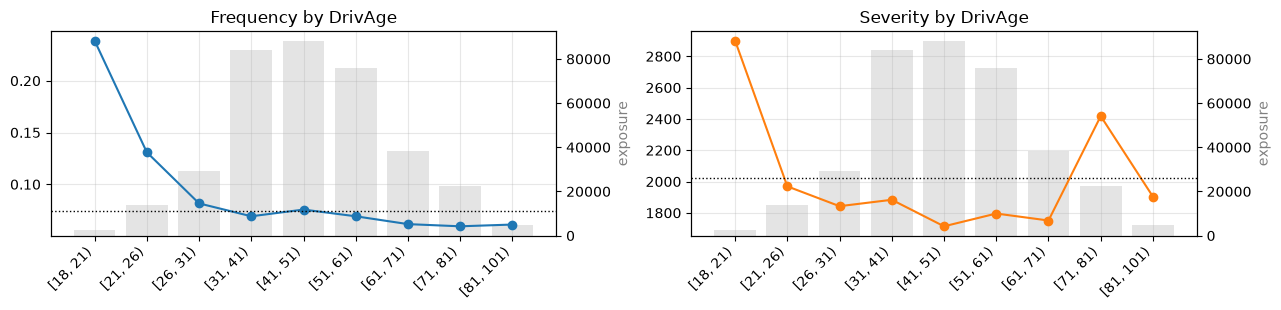

In [7]:
plot_oneway(df, "DrivAge", bins=[18, 21, 26, 31, 41, 51, 61, 71, 81, 101])

Strong signal for frequency: very high for 18–25-year-olds, falling to a minimum in middle age, then rising slightly for older drivers. This is the classic U-shape. The effect on severity is much weaker.

### Bonus-Malus

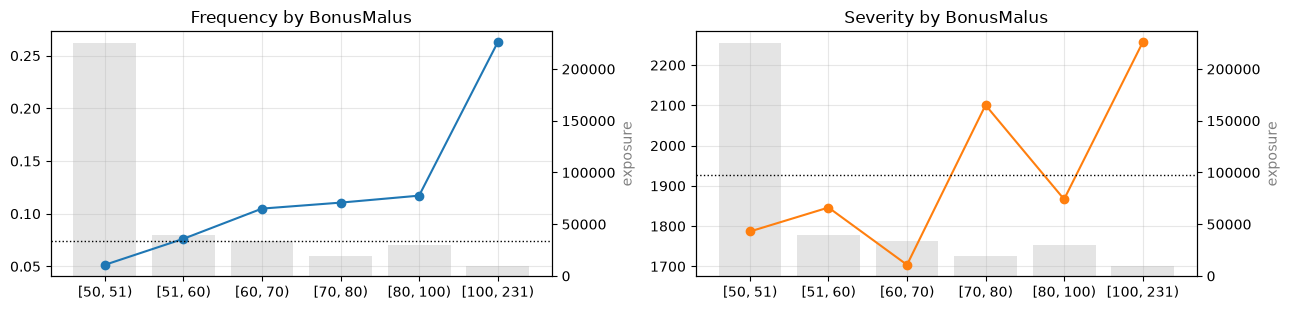

In [8]:
plot_oneway(df, "BonusMalus", bins=[50, 51, 60, 70, 80, 100, 231])

The strongest frequency predictor. `BonusMalus` summarises the driver's *own claims history*, so it's not surprising that it predicts future claims. Most exposure sits at 50 (the best level).

### Vehicle age and power

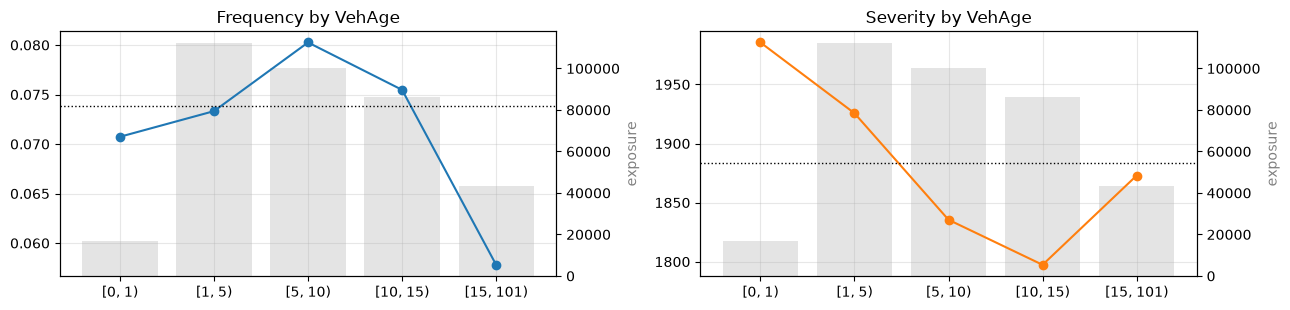

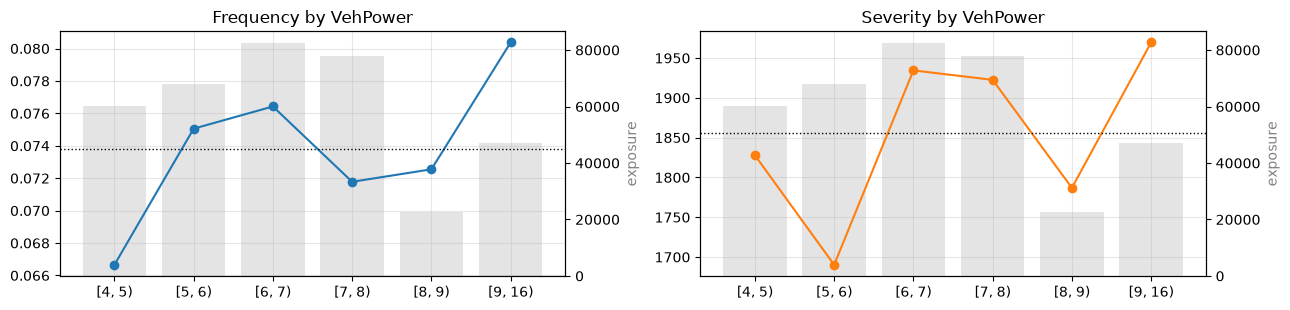

In [9]:
plot_oneway(df, "VehAge", bins=[0, 1, 5, 10, 15, 101])
plot_oneway(df, "VehPower", bins=[4, 5, 6, 7, 8, 9, 16])

New vehicles (age 0) have a higher frequency. Possible reasons are a new driver–car combination, or more comprehensive reporting on financed cars. `VehPower` has a mild effect.

### Location: Area, Density, Region

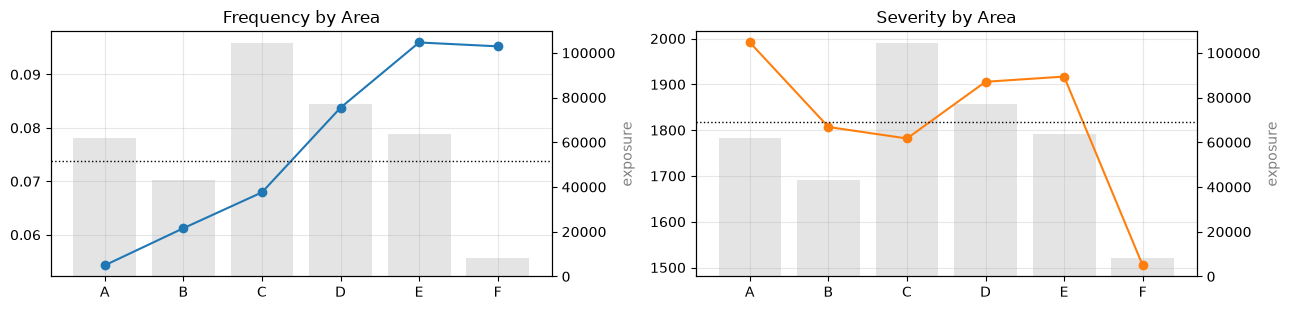

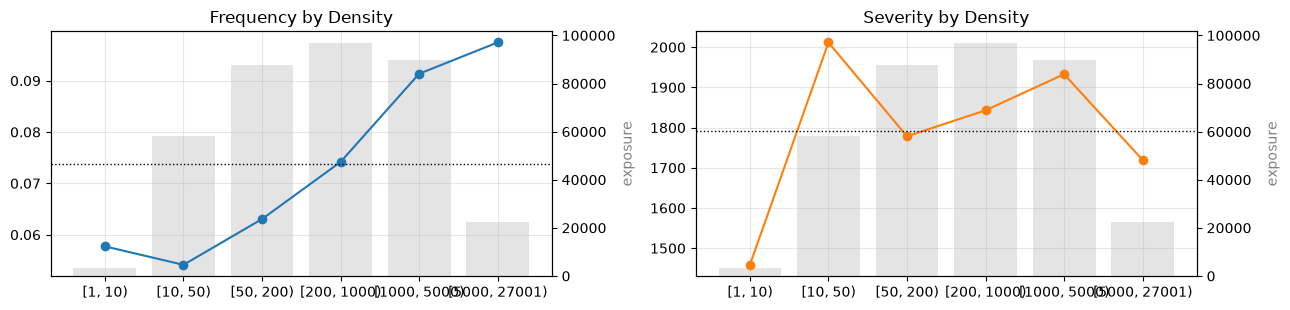

In [10]:
plot_oneway(df, "Area")
plot_oneway(df, "Density", bins=[1, 10, 50, 200, 1000, 5000, 27001])

In [11]:
# How related are Area and Density?
df.groupby("Area", observed=True).Density.agg(["min", "median", "max"])

,min,median,max
Area,,,
A,1,27.0,50
B,50,72.0,100
C,100,222.0,500
D,500,1054.0,1993
E,2001,3744.0,9850
F,10008,27000.0,27000


Frequency rises steadily with urbanisation. The table shows that **`Area` is essentially a banded version of `Density`**: the density ranges of the Area levels hardly overlap. Including both would double-count the same effect, so the baseline uses only `Area` (6 levels, easy to explain). Whether the more granular `Density` (or `Region`) adds value is a question for the next modelling phase.

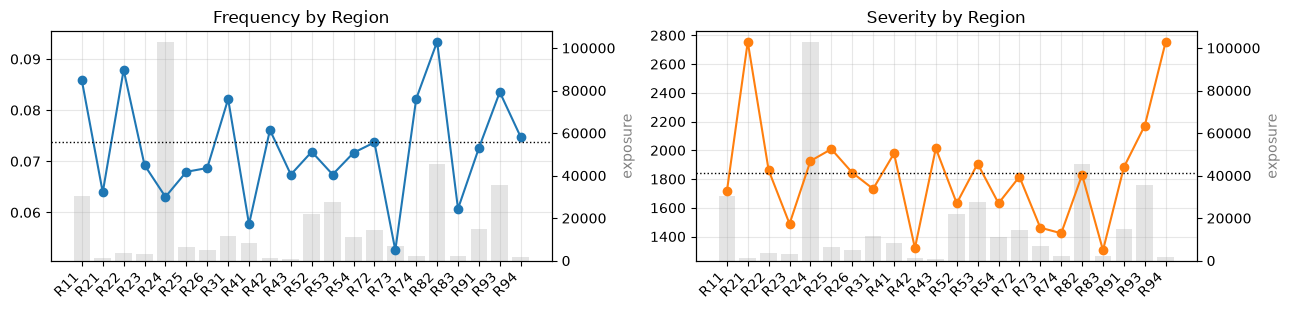

In [12]:
plot_oneway(df, "Region")

### Vehicle brand and fuel

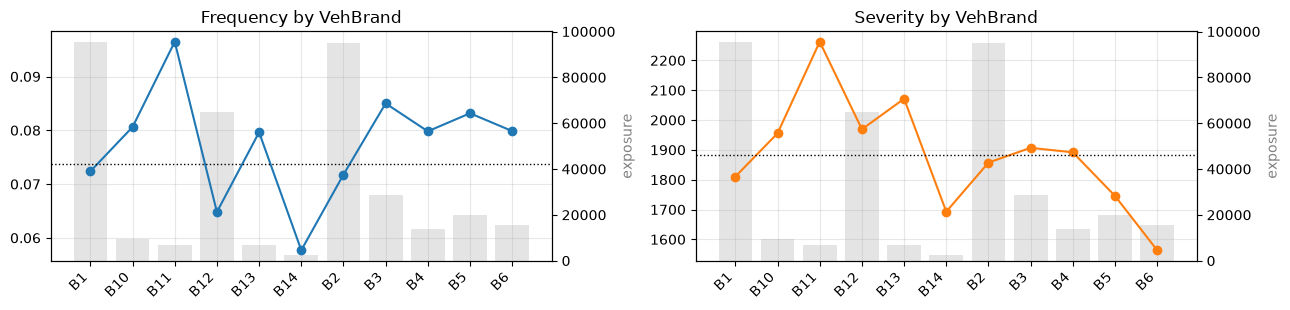

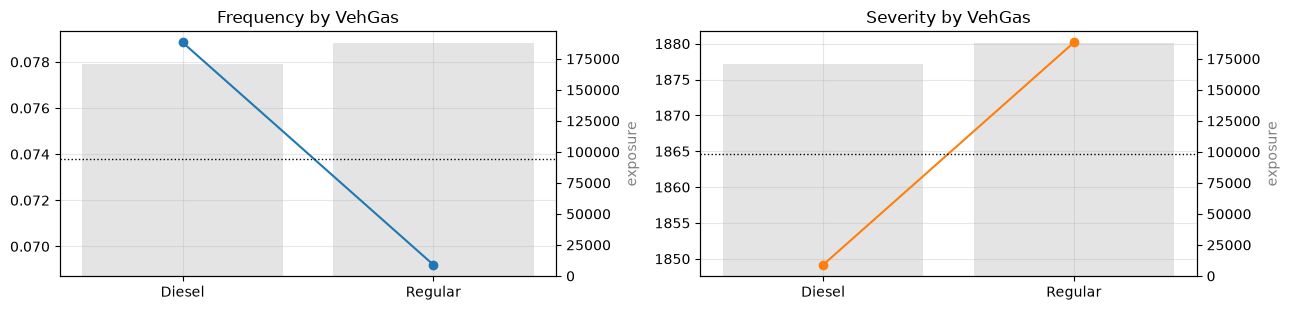

In [13]:
plot_oneway(df, "VehBrand")
plot_oneway(df, "VehGas")

## 5. Baseline feature set

The baseline should be **simple, clearly relevant and easy to explain**. Every later model is compared against it.

| Feature | Treatment | Reason |
|---|---|---|
| `DrivAge` | 7 bands | strong U-shape; bands capture the shape without assuming a formula |
| `BonusMalus` | 6 bands | strongest predictor |
| `VehAge` | 5 bands | clear new-car effect |
| `VehPower` | 4–8, 9+ | mild effect; the top levels are thin, so they're grouped |
| `Area` | as is (A–F) | location effect; stands in for `Density` |
| `VehGas` | as is | simple 2-level factor |
| `Region`, `VehBrand`, `Density` | **left out** | many levels, or overlapping with `Area`; they're candidates for the feature-search phase |

**Why bands instead of continuous values?** Each band gets its own relativity, which is the format of a classic rating table: transparent and easy to challenge. The cost is some lost precision at band edges. Splines or other smooth effects are possible later improvements.

**Base levels:** in a GLM with categorical factors, one level of each factor is the *reference* (relativity = 1.00), and the other levels are expressed relative to it. We pick the level with the **most exposure** as the reference. That's the actuarial convention: the base premium then describes the most common risk, and the relativities' standard errors are smallest.

In [14]:
BANDS = {
    "DrivAge":    ([18, 21, 26, 31, 41, 51, 71, 101], ["18-20", "21-25", "26-30", "31-40", "41-50", "51-70", "71+"]),
    "BonusMalus": ([50, 51, 60, 70, 80, 100, 231],    ["50", "51-59", "60-69", "70-79", "80-99", "100+"]),
    "VehAge":     ([0, 1, 5, 10, 15, 101],            ["0", "1-4", "5-9", "10-14", "15+"]),
    "VehPower":   ([4, 5, 6, 7, 8, 9, 16],            ["4", "5", "6", "7", "8", "9+"]),
}
CATEGORICAL = ["Area", "VehGas"]
FEATURES = list(BANDS) + CATEGORICAL


def make_features(data):
    # Turn raw rating factors into the banded categorical design used by the GLMs
    X = pd.DataFrame(index=data.index)
    for var, (edges, labels) in BANDS.items():
        X[var] = pd.cut(data[var], edges, right=False, labels=labels)
    for var in CATEGORICAL:
        X[var] = data[var].astype("category")
    return X


def set_base_levels(X, exposure):
    # Reorder categories so the highest-exposure level comes first (glum's drop_first uses it as the reference)
    X = X.copy()
    for var in X.columns:
        base = exposure.groupby(X[var], observed=True).sum().idxmax()
        cats = list(X[var].cat.categories)
        X[var] = X[var].cat.reorder_categories([base] + [c for c in cats if c != base])
    return X


X_all = set_base_levels(make_features(df), df.Exposure)
assert X_all.notna().all().all(), "some values fall outside the band edges"
{var: X_all[var].cat.categories[0] for var in FEATURES}   # reference level per factor

{'DrivAge': '51-70',
 'BonusMalus': '50',
 'VehAge': '1-4',
 'VehPower': '6',
 'Area': 'C',
 'VehGas': 'Regular'}

## 6. Train / test split

80% of policies are used to **fit** the models and 20% are held out to **evaluate** them. Performance on unseen data is the honest measure; a model can always fit its own training data well.

The split is at **policy level** with a fixed seed, so it's the same every time the notebook runs. That matters when comparing the baseline with future candidates.

In [15]:
idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=SEED)
train, test = df.loc[idx_train], df.loc[idx_test]
X_train, X_test = X_all.loc[idx_train], X_all.loc[idx_test]
print(f"train: {len(train):,} policies, {train.Exposure.sum():,.0f} years | test: {len(test):,} policies, {test.Exposure.sum():,.0f} years")

train: 542,410 policies, 286,764 years | test: 135,603 policies, 71,596 years


## 7. Frequency model: Poisson GLM

**Model.** For policy $i$ with exposure $e_i$ and rating factors $x_i$:

$$
N_i \sim \text{Poisson}(e_i \lambda_i), \qquad \log \lambda_i = \beta_0 + \sum_j \beta_j x_{ij}
$$

- $\lambda_i$ is the **annual claim frequency** we want to predict.
- **Poisson** is the standard distribution for counts of rare, independent events. Its variance equals its mean.
- The **log link** makes effects multiplicative: $\lambda_i = e^{\beta_0} \times e^{\beta_1 x_{i1}} \times \dots$, so $e^{\beta_j}$ is directly the **relativity** of a factor level.

**Handling exposure.** A policy insured for half a year should have half the expected claims. The textbook way is an *offset* $\log e_i$. The equivalent approach used here, and recommended by glum, is to model the **rate** $y_i = N_i / e_i$ with **sample weight** $e_i$. Both give exactly the same coefficients for a Poisson GLM with a log link.

**`glum` settings**
- `family="poisson", link="log"`: as above.
- `alpha=0`: **no regularisation**, i.e. plain maximum likelihood, the classical actuarial GLM. Regularisation (ridge/lasso) is something to try later in the feature search.
- `drop_first=True`: drops the first (reference) level of each factor, which we set to the highest-exposure level. Without this, the factor levels and the intercept would be perfectly collinear.

In [16]:
y_freq_train = train.ClaimNbFreq / train.Exposure

freq_glm = GeneralizedLinearRegressor(family="poisson", link="log", alpha=0, drop_first=True)
freq_glm.fit(X_train, y_freq_train, sample_weight=train.Exposure)

freq_coefs = freq_glm.coef_table(X=X_train, y=y_freq_train, sample_weight=train.Exposure)
freq_coefs

,coef,se,t_value,p_value,ci_lower,ci_upper
intercept,-3.040593,0.027362,-111.124923,0.000000e+00,-3.094222,-2.986965
DrivAge[18-20],0.182142,0.051425,3.541897,3.972601e-04,0.081351,0.282934
DrivAge[21-25],-0.258141,0.033873,-7.620869,2.509104e-14,-0.324530,-0.191751
DrivAge[26-30],-0.536541,0.029543,-18.161331,0.000000e+00,-0.594444,-0.478638
DrivAge[31-40],-0.326632,0.021540,-15.164117,0.000000e+00,-0.368849,-0.284414
DrivAge[41-50],0.055774,0.019476,2.863646,4.187958e-03,0.017601,0.093947
DrivAge[71+],0.014016,0.031925,0.439032,6.606383e-01,-0.048556,0.076588
BonusMalus[51-59],0.485804,0.024649,19.708695,0.000000e+00,0.437492,0.534115
BonusMalus[60-69],0.856245,0.023915,35.803061,0.000000e+00,0.809371,0.903118
BonusMalus[70-79],0.939050,0.029030,32.347170,0.000000e+00,0.882151,0.995948


**Reading the table**
- `coef` is $\beta$, on the log scale. The relativity is $e^{\beta}$; for example, a coefficient of 0.69 means about 2× the frequency of the reference level.
- `se` is the standard error: how uncertain the estimate is, smaller with more data.
- `p_value` tests whether the level differs from the reference. A small value (< 0.05) means the difference is unlikely to be noise.

**Notable: young drivers.** In the one-way, drivers aged 18–25 had by far the highest frequency. In the GLM, the 21–30 bands get a *discount* relative to 51–70. This isn't a bug: it's the confounding problem from section 4 showing up. New drivers in France **start on a malus** (`BonusMalus` ≈ 100), so most of the young-driver risk is already captured by the `BonusMalus` relativity. The GLM splits the effect between the two correlated factors, and `DrivAge` only shows what remains *given* `BonusMalus`. The *combined* premium for a typical young driver is still high. An actuary would review this split, and a `DrivAge × BonusMalus` interaction is a natural candidate for the next phase.

## 8. Severity model: Gamma GLM

**Data.** Only policies **with at least one claim**; a policy without claims tells us nothing about claim size.

**Model.** For policy $i$ with $n_i$ claims and average (capped) claim amount $\bar{X}_i$:

$$
\bar{X}_i \sim \text{Gamma}\left(\mu_i,\ \phi / n_i\right), \qquad \log \mu_i = \gamma_0 + \sum_j \gamma_j x_{ij}
$$

- **Gamma** is a standard choice for claim amounts: strictly positive and right-skewed, with **variance ∝ mean²**. In other words, the *relative* spread (the coefficient of variation) is the same for cheap and expensive risks, which suits money amounts.
- **Weight $n_i$.** An average of $n_i$ claims is more reliable than a single claim (its variance is divided by $n_i$), so it gets proportionally more weight.
- **Log link**, as before, makes the severity relativities multiplicative and compatible with frequency.

**Capped claims + large-loss loading.** The model is fitted on claims capped at €100k. The removed part is added back as a flat factor:

$$
\text{loading} = \frac{\text{total uncapped cost}}{\text{total capped cost}} \quad \text{(on the training data)}
$$

In [17]:
sev_train = train[train.ClaimCount > 0]
X_sev_train = X_train.loc[sev_train.index]
y_sev_train = sev_train.ClaimAmountCapped / sev_train.ClaimCount

sev_glm = GeneralizedLinearRegressor(family="gamma", link="log", alpha=0, drop_first=True)
sev_glm.fit(X_sev_train, y_sev_train, sample_weight=sev_train.ClaimCount)

large_loss_loading = train.ClaimAmount.sum() / train.ClaimAmountCapped.sum()
print(f"Policies with claims (train): {len(sev_train):,}")
print(f"Large-loss loading: {large_loss_loading:.4f}")

sev_coefs = sev_glm.coef_table(X=X_sev_train, y=y_sev_train, sample_weight=sev_train.ClaimCount)
sev_coefs

Policies with claims (train): 19,843
Large-loss loading: 1.2350


,coef,se,t_value,p_value,ci_lower,ci_upper
intercept,7.513937,0.075440,99.601110,0.000000e+00,7.366077,7.661797
DrivAge[18-20],0.418951,0.150288,2.787660,5.309018e-03,0.124393,0.713510
DrivAge[21-25],-0.027116,0.093100,-0.291256,7.708552e-01,-0.209588,0.155356
DrivAge[26-30],-0.072056,0.073697,-0.977724,3.282107e-01,-0.216500,0.072389
DrivAge[31-40],0.012502,0.055005,0.227280,8.202062e-01,-0.095307,0.120310
DrivAge[41-50],-0.084846,0.046197,-1.836603,6.626855e-02,-0.175391,0.005699
DrivAge[71+],0.212337,0.102291,2.075810,3.791156e-02,0.011850,0.412825
BonusMalus[51-59],0.095018,0.064298,1.477782,1.394663e-01,-0.031003,0.221040
BonusMalus[60-69],-0.070196,0.047171,-1.488114,1.367208e-01,-0.162651,0.022258
BonusMalus[70-79],0.196167,0.081072,2.419656,1.553520e-02,0.037268,0.355066


Compared with frequency, severity standard errors are much larger and fewer levels are significant. This is typical: there are about 20× fewer claims than policies, and claim size depends mostly on the accident itself, not on the rating factors. Severity relativities are therefore usually closer to 1.

## 9. Risk premium

$$
\widehat{\text{RP}}_i = \hat{\lambda}_i \times \hat{\mu}_i \times \text{loading}
$$

This is the expected claims cost **per year of exposure**. Multiply by the exposure to get the expected cost of a policy.

In [18]:
def predict_risk_premium(X):
    out = pd.DataFrame(index=X.index)
    out["freq"] = freq_glm.predict(X)
    out["sev"] = sev_glm.predict(X) * large_loss_loading
    out["risk_premium"] = out.freq * out.sev
    return out


pred_test = predict_risk_premium(X_test)
pred_test.describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
freq,135603.0,0.079422,0.053252,0.016302,0.035603,0.062235,0.175643,0.576493
sev,135603.0,2249.191531,365.518181,1084.321488,1747.659363,2212.185933,2851.078831,5007.427180
risk_premium,135603.0,184.651414,161.042394,30.830214,75.005734,136.593678,432.850425,2668.322936


## 10. Evaluation on the test set

Four views, each answering a different question:

1. **Calibration**: is the *total* predicted cost close to the actual total? (Is the premium level right?)
2. **Deviance explained**: how much better than a flat, one-premium-for-everyone model? (Does it fit?)
3. **Lift chart**: when sorted by predicted risk, do actual costs rise accordingly? (Does it rank risks?)
4. **Gini / Lorenz curve**: a single number summarising how well the model separates good and bad risks.

### 10.1 Calibration

In [19]:
test_sev = test[test.ClaimCount > 0]
pd.DataFrame({
    "predicted": [
        (pred_test.freq * test.Exposure).sum(),
        (sev_glm.predict(X_test.loc[test_sev.index]) * test_sev.ClaimCount).sum(),
        (pred_test.risk_premium * test.Exposure).sum(),
    ],
    "actual": [test.ClaimCount.sum(), test_sev.ClaimAmountCapped.sum(), test.ClaimAmount.sum()],
}, index=["claim count", "capped cost (given claims)", "total cost (uncapped)"]).assign(
    ratio=lambda t: t.predicted / t.actual
).style.format("{:,.3f}")

,predicted,actual,ratio
claim count,"5,264.090","5,400.000",0.975
capped cost (given claims),"10,008,367.458","10,401,006.470",0.962
total cost (uncapped),"12,038,699.499","11,868,103.840",1.014


Claim count and capped severity should be close to 1.0. The uncapped total cost is noisier: a single €1m claim landing in the test set moves it by several percent. That's exactly why large losses are handled by a loading, not by the model.

### 10.2 Deviance explained

**Deviance** is the GLM version of squared error (smaller is better). We compare it with a **null model** that predicts the training-set average for everyone:

$$
D^2 = 1 - \frac{\text{deviance(model)}}{\text{deviance(null)}}
$$

Values of only a few percent are **normal** for insurance frequency. Claims are mostly random, so even a perfect tariff can't predict *who* crashes, only *who is more likely to*.

In [20]:
y_freq_test = test.ClaimNbFreq / test.Exposure
null_freq = np.full(len(test), train.ClaimNbFreq.sum() / train.Exposure.sum())
d_freq = mean_poisson_deviance(y_freq_test, pred_test.freq, sample_weight=test.Exposure)
d_freq0 = mean_poisson_deviance(y_freq_test, null_freq, sample_weight=test.Exposure)

y_sev_test = test_sev.ClaimAmountCapped / test_sev.ClaimCount
pred_sev_test = sev_glm.predict(X_test.loc[test_sev.index])
null_sev = np.full(len(test_sev), y_sev_train.mul(sev_train.ClaimCount).sum() / sev_train.ClaimCount.sum())
d_sev = mean_gamma_deviance(y_sev_test, pred_sev_test, sample_weight=test_sev.ClaimCount)
d_sev0 = mean_gamma_deviance(y_sev_test, null_sev, sample_weight=test_sev.ClaimCount)

pd.DataFrame({
    "deviance (model)": [d_freq, d_sev],
    "deviance (null)": [d_freq0, d_sev0],
    "D² (deviance explained)": [1 - d_freq / d_freq0, 1 - d_sev / d_sev0],
}, index=["frequency (Poisson)", "severity (Gamma)"]).style.format("{:.4f}")

,deviance (model),deviance (null),D² (deviance explained)
frequency (Poisson),0.4645,0.4858,0.0439
severity (Gamma),1.3935,1.3735,-0.0146


**Interpreting the result**
- **Frequency:** a few percent deviance explained on unseen data. That's a typical level for motor frequency, and the model clearly beats the flat premium.
- **Severity:** D² is around zero or **negative**: on the test set, the severity factors predict claim size no better (or slightly worse) than a single average claim. The coefficients fit noise in the ~20k training claims rather than real structure, which is called *overfitting*. This is a common and honest finding for severity on this dataset.

**What this means for the tariff:** most of the risk differentiation comes from frequency. Options for the next phase: a severity model with fewer factors (or intercept-only), or regularisation (`alpha > 0`), which shrinks noisy coefficients towards zero. The baseline deliberately keeps the simple, unregularised version, so that the improvement can be *measured*.

### 10.3 Lift chart

Test policies are sorted by predicted risk premium and grouped into 10 bands of equal exposure. For each band we compare the **average predicted** with the **average actual** cost per year. A good model shows actuals rising from left to right and tracking the predictions.

bin,1,2,3,4,5,6,7,8,9,10
predicted,70.5,88.7,100.5,111.4,121.8,135.2,154.7,186.4,242.1,470.3
actual,65.1,126.8,114.7,101.8,135.9,138.8,176.2,203.0,292.7,439.1


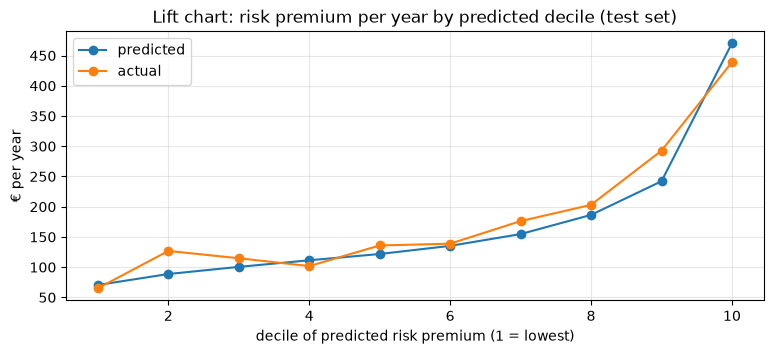

In [21]:
def lift_table(actual_cost, predicted_rate, exposure, n_bins=10):
    t = pd.DataFrame({"actual": actual_cost, "pred": predicted_rate * exposure, "rate": predicted_rate, "expo": exposure})
    t = t.sort_values("rate")
    t["bin"] = np.minimum((t.expo.cumsum() / t.expo.sum() * n_bins).astype(int), n_bins - 1) + 1
    g = t.groupby("bin")[["actual", "pred", "expo"]].sum()
    return pd.DataFrame({"predicted": g.pred / g.expo, "actual": g.actual / g.expo})


lift = lift_table(test.ClaimAmountCapped * large_loss_loading, pred_test.risk_premium, test.Exposure)
ax = lift.plot(marker="o", title="Lift chart: risk premium per year by predicted decile (test set)")
ax.set_xlabel("decile of predicted risk premium (1 = lowest)")
ax.set_ylabel("€ per year")
lift.T.round(1)

Actual cost here is the **capped cost × loading**, so that one huge claim landing in a single decile doesn't hide the pattern. The ratio between the top and bottom decile shows how strongly the tariff differentiates.

### 10.4 Lorenz curve and Gini

Sort policies from **lowest to highest predicted risk** and plot the cumulative share of exposure (x-axis) against the cumulative share of actual claims cost (y-axis).
- A model with no skill gives the diagonal: the first 50% of exposure brings 50% of the cost.
- A good model bends the curve downwards: the "good" half of the portfolio brings far less than half the cost.
- **Gini = 2 × the area between the diagonal and the curve.** It is 0 for no skill, and higher is better. It measures **ranking only**, not the premium level, which is why it's always shown together with calibration.

Gini, frequency model vs claim counts: 0.286
Gini, risk premium vs capped cost: 0.298


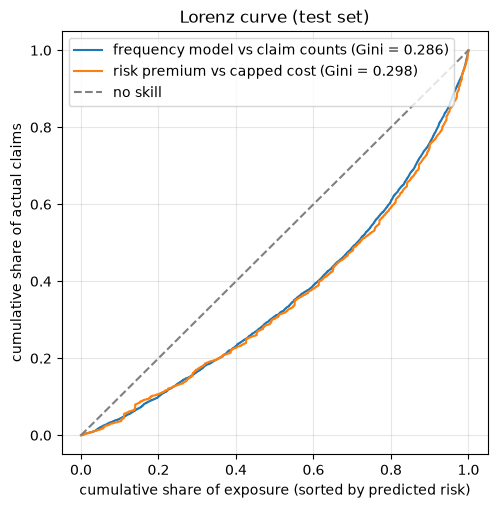

In [22]:
def lorenz(actual_cost, predicted_rate, exposure):
    order = np.argsort(predicted_rate)
    cum_expo = np.concatenate([[0], np.cumsum(exposure[order]) / exposure.sum()])
    cum_cost = np.concatenate([[0], np.cumsum(actual_cost[order]) / actual_cost.sum()])
    gini = 1 - 2 * np.trapezoid(cum_cost, cum_expo)
    return cum_expo, cum_cost, gini


expo_t = test.Exposure.to_numpy()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for label, actual, rate in [
    ("frequency model vs claim counts", test.ClaimNbFreq.to_numpy(), pred_test.freq.to_numpy()),
    ("risk premium vs capped cost", test.ClaimAmountCapped.to_numpy(), pred_test.risk_premium.to_numpy()),
]:
    x, y, g = lorenz(actual, rate, expo_t)
    ax.plot(x, y, label=f"{label} (Gini = {g:.3f})")
    print(f"Gini, {label}: {g:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="no skill")
ax.set_xlabel("cumulative share of exposure (sorted by predicted risk)")
ax.set_ylabel("cumulative share of actual claims")
ax.set_title("Lorenz curve (test set)")
ax.legend(loc="upper left")

## 11. The tariff: relativity tables

This is the **explainable output** of the model, in the form a pricing actuary or regulator would review.

The risk premium of any policy is:

$$
\text{RP} = \underbrace{e^{\beta_0} \cdot e^{\gamma_0} \cdot \text{loading}}_{\text{base premium}} \times \prod_{\text{factors}} \underbrace{\left(\text{freq rel.} \times \text{sev rel.}\right)}_{\text{combined relativity}}
$$

The **base premium** is the premium of a policy with every factor at its reference level. Each factor then multiplies it up or down.

In [23]:
def relativities(glm, X):
    # One row per factor level: relativity exp(beta), reference level = 1.0
    coefs = pd.Series(glm.coef_, index=glm.feature_names_)
    rows = []
    for var in X.columns:
        for i, level in enumerate(X[var].cat.categories):
            beta = 0.0 if i == 0 else coefs[[n for n in coefs.index if n.startswith(var) and n.endswith(f"{level}]")][0]]
            rows.append((var, level, np.exp(beta)))
    return pd.DataFrame(rows, columns=["factor", "level", "rel"]).set_index(["factor", "level"]).rel


exposure_by_level = pd.concat({var: train.Exposure.groupby(X_train[var], observed=True).sum() for var in FEATURES})
exposure_by_level.index.names = ["factor", "level"]

tariff = pd.DataFrame({
    "exposure": exposure_by_level,
    "freq_rel": relativities(freq_glm, X_train),
    "sev_rel": relativities(sev_glm, X_train),
})
tariff["combined_rel"] = tariff.freq_rel * tariff.sev_rel

base_premium = np.exp(freq_glm.intercept_) * np.exp(sev_glm.intercept_) * large_loss_loading
print(f"Base premium (all factors at reference level): €{base_premium:,.2f} per year")
print("Reference levels:", {var: X_train[var].cat.categories[0] for var in FEATURES})

Base premium (all factors at reference level): €108.24 per year
Reference levels: {'DrivAge': '51-70', 'BonusMalus': '50', 'VehAge': '1-4', 'VehPower': '6', 'Area': 'C', 'VehGas': 'Regular'}


In [24]:
# show levels in their natural (banded) order rather than reference-first
natural_order = {var: labels for var, (_, labels) in BANDS.items()} | {var: sorted(X_all[var].cat.categories) for var in CATEGORICAL}
tariff_display = pd.concat({var: tariff.loc[var].reindex(natural_order[var]) for var in FEATURES}, names=["factor", "level"])
tariff_display.style.format({"exposure": "{:,.0f}", "freq_rel": "{:.3f}", "sev_rel": "{:.3f}", "combined_rel": "{:.3f}"}) \
    .background_gradient(subset=["combined_rel"], cmap="RdYlGn_r", vmin=0.5, vmax=2.0)

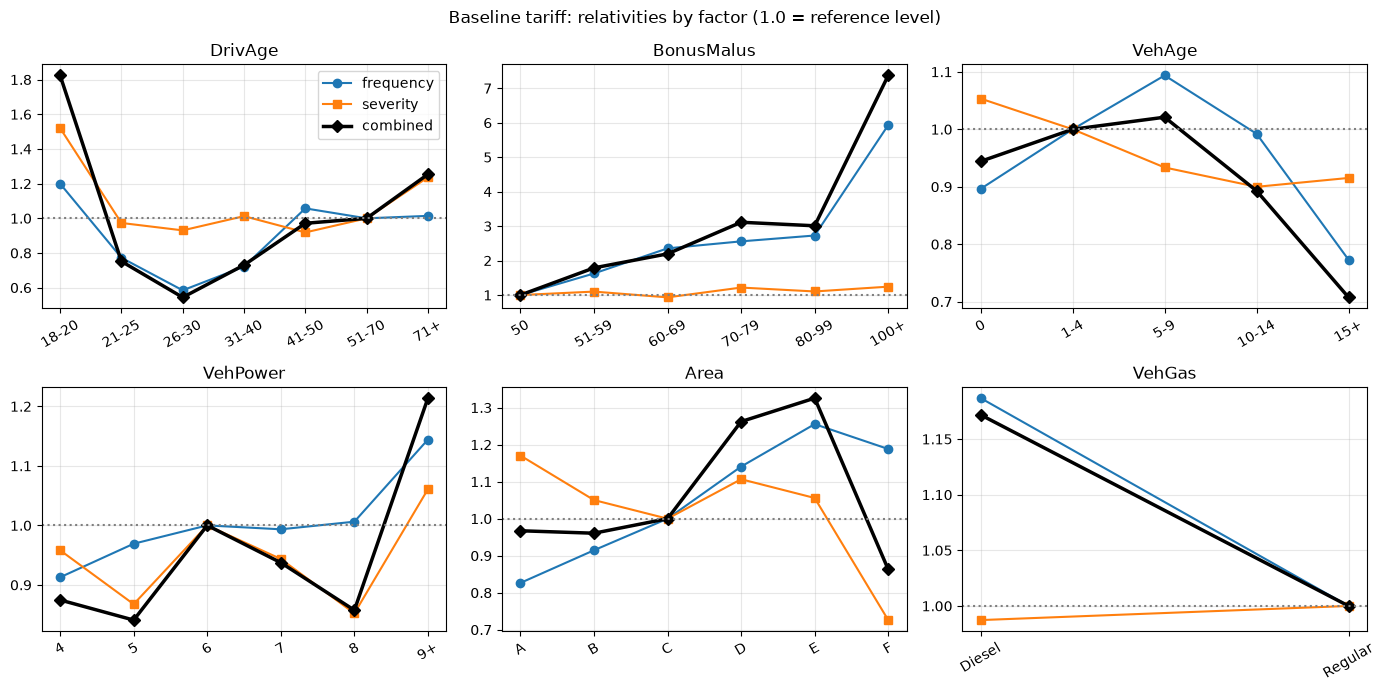

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, var in zip(axes.flat, FEATURES):
    t = tariff_display.loc[var]
    x = np.arange(len(t))
    ax.plot(x, t.freq_rel, marker="o", label="frequency")
    ax.plot(x, t.sev_rel, marker="s", label="severity")
    ax.plot(x, t.combined_rel, marker="D", lw=2.5, color="black", label="combined")
    ax.axhline(1, color="grey", ls=":")
    ax.set_xticks(x, t.index, rotation=30)
    ax.set_title(var)
axes.flat[0].legend()
fig.suptitle("Baseline tariff: relativities by factor (1.0 = reference level)")
plt.tight_layout()

### Worked example

How the tariff prices one test policy, factor by factor. This step-by-step breakdown is what makes a GLM tariff **explainable**: every euro of the premium can be traced to a factor.

In [26]:
example_id = X_test.index[0]
policy = X_test.loc[example_id]
steps = [("base premium", "", base_premium)]
running = base_premium
for var in FEATURES:
    rel = tariff.loc[(var, policy[var]), "combined_rel"]
    running *= rel
    steps.append((var, policy[var], rel))
breakdown = pd.DataFrame(steps, columns=["factor", "level", "multiplier"])
breakdown["premium after step"] = breakdown.multiplier.cumprod()
print(f"Tariff result: €{running:,.2f}  |  model prediction: €{pred_test.loc[example_id, 'risk_premium']:,.2f}")
breakdown.style.format({"multiplier": "{:.3f}", "premium after step": "€{:,.2f}"})

Tariff result: €199.21  |  model prediction: €199.21


,factor,level,multiplier,premium after step
0,base premium,,108.243,€108.24
1,DrivAge,31-40,0.730,€79.06
2,BonusMalus,80-99,3.009,€237.93
3,VehAge,15+,0.708,€168.34
4,VehPower,7,0.937,€157.81
5,Area,D,1.262,€199.21
6,VehGas,Regular,1.000,€199.21


## 12. Summary and next steps

**Baseline model**
- Frequency: Poisson GLM, 6 banded factors, exposure as sample weight.
- Severity: Gamma GLM on claims capped at €100k, claim count as weight, plus a large-loss loading.
- Risk premium = frequency × severity × loading, expressed as a base premium × relativity table.

**Its role:** this is the **benchmark**. Every candidate model in the next phases must show a better test-set deviance / Gini **and** stay well calibrated, without losing explainability.

**Candidate improvements for the next phases**
1. Add `Region`, `VehBrand` and `Density`, possibly with grouping of thin levels.
2. Smooth effects (splines) instead of bands for `DrivAge` and `BonusMalus`.
3. Interactions, e.g. young driver × high vehicle power.
4. Regularisation (`alpha > 0` in glum) to stabilise thin levels, especially for severity.
5. A separate model for large losses instead of a flat loading.

**Not done yet (on purpose):** logging these models to MLflow. That's the next step, to be done together.